# Computational Creativity Assignment 1: The Great Bitwise Bake Off

In [17]:
import json
import random
import pprint
import matplotlib.pyplot as plt

In [18]:
# Load the inspiring set
inspiring_set = json.load(open("configs/init_recipes.json"))["seed_recipes"]


In [19]:
# Fitness function
# ! Give them random fitness scores for now (You can remove this when making the fitness function)
def fitness_function(recipes):
    fitness_scores = [random.randint(1, 100) for _ in recipes]
    return fitness_scores


In [20]:
# Selection strategy, roulette wheel
# TODO: Improve this, maybe a better selection strategy?
def select_parent(recipes, fitness_scores):
    parent = random.choices(recipes, weights=fitness_scores, k=1)[0]
    return parent


In [21]:
# Crossover function, randomly selects genes from parents
# TODO: Improve this by a lot
def crossover(parent1, parent2):
    child = {}
    child["id"] = f"{parent1['id'][:4]}{parent2['id'][-4:]}"
    child["name"] = f"{parent1['name'][:4]}{parent2['name'][-4:]}"

    p1_ingredients = parent1["ingredients_g"]
    p2_ingredients = parent2["ingredients_g"]
    c_ingredients = {}

    # Iterate over both parents' ingredients and randomly select from either parent
    for (k, v), (k2, v2) in zip(p1_ingredients.items(), p2_ingredients.items()):
        chosen = random.choice([k, k2])
        c_ingredients[chosen] = v if chosen == k else v2

    child["ingredients_g"] = c_ingredients 
    return child


In [22]:
# Mutation function, randomly changes an ingredient based on mutation rate
# ! Untested as we do not have an ingredient list yet
mutation_rate = 0.1

def mutate(recipe):
    for ingredient in recipe:
        if random.random() < mutation_rate:
            recipe[ingredient] = random.choice(ingredient_list[ingredient])
    return recipe


In [ ]:
# Normalisation
# TODO: Implement
def normalise(recipe):
    return recipe

In [24]:
# Generate new generation
def generate_new_generation(recipes, population_size, fitness_scores):
    new_generation = []
    for _ in range(population_size):
        p1 = select_parent(recipes, fitness_scores)
        p2 = select_parent(recipes, fitness_scores)
        child = crossover(p1, p2)
        # child = mutate(child)
        child = normalise(child)
        new_generation.append(child)
    return new_generation

In [47]:
# Genetic Algorithm Loop
population = inspiring_set
population_size = len(inspiring_set)
n_generations = 100

best_fitness_scores = []

for generation in range(n_generations):
    population = generate_new_generation(population, population_size, fitness_scores)

    fitness_scores = fitness_function(population)
    best_fitness_scores.append(max(fitness_scores))

pprint.pprint(population[1])

{'id': 'clastter',
 'ingredients_g': {'butter_unsalted': 170, 'flour_ap': 300, 'sugar_brown': 130},
 'name': 'Claskies'}


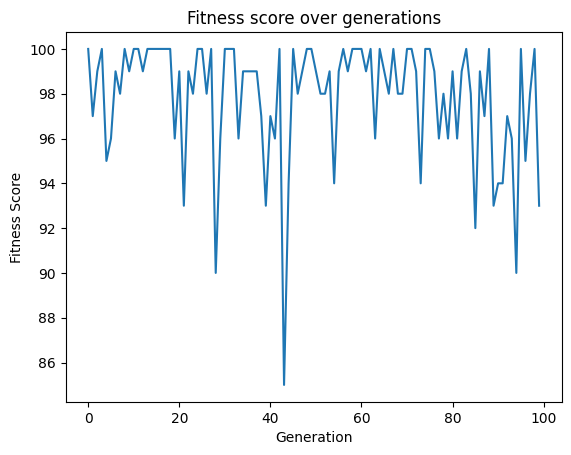

In [28]:
# Plot results
plt.plot(range(n_generations), best_fitness_scores)
plt.xlabel("Generation")
plt.ylabel("Fitness Score")
plt.title("Fitness score over generations")
plt.show()
